/tmp/ipykernel_4602/1247203746.py:114: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({



=== DISTRIBUIÇÃO DOS CLUSTERS ===
Cluster
2    2918
1    2212
0    1913
Name: count, dtype: int64

=== RECALL MÉDIO ===
Random Forest: 0.8842
Regressão Logística: 0.8486
MLP: 0.8491

🏆 Melhor Modelo: RF

=== RESULTADO FINAL ===
Accuracy: 0.7572746628814763
Precision: 0.5297397769516728
Recall: 0.7620320855614974
F1-Score: 0.625


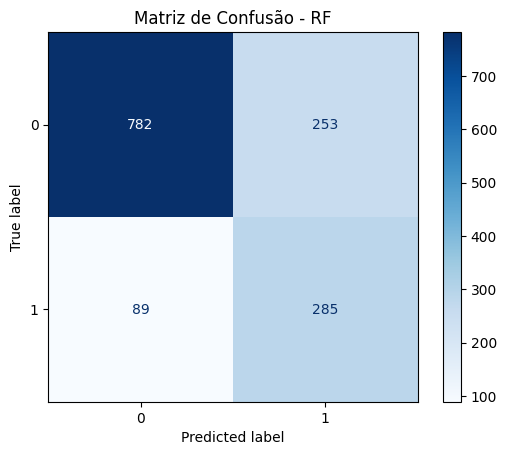


=== PROCESSANDO SHAP ===

Gerando gráfico SHAP Summary Plot...


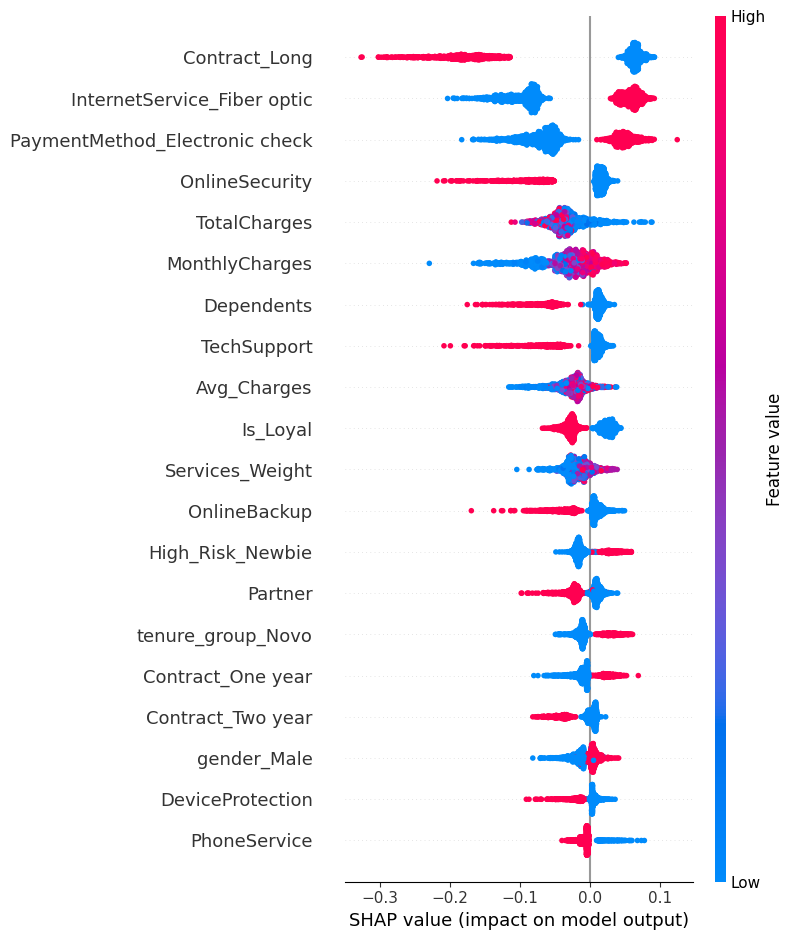


=== VALIDAÇÃO CIENTÍFICA ===
ROC-AUC Final: 0.8269


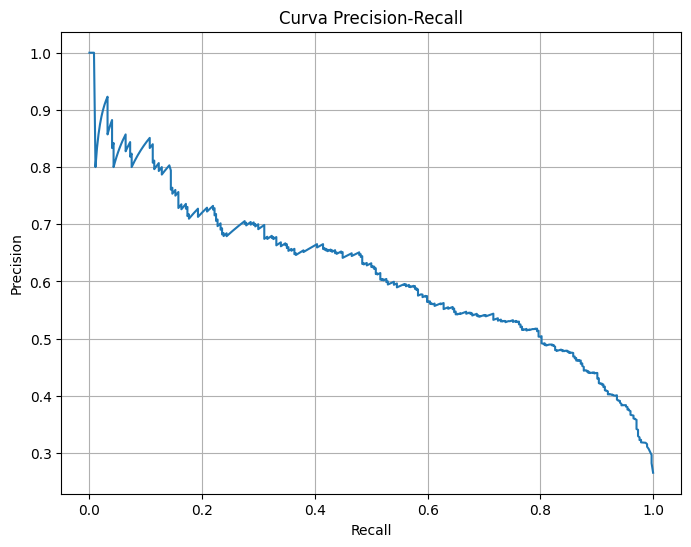


=== TESTE DE WILCOXON ===
RF vs LR -> p-value: 0.0020
RF vs MLP -> p-value: 0.0020
Diferença estatisticamente significativa entre RF e LR
Diferença estatisticamente significativa entre RF e MLP

=== CURVA DE CALIBRAÇÃO ===


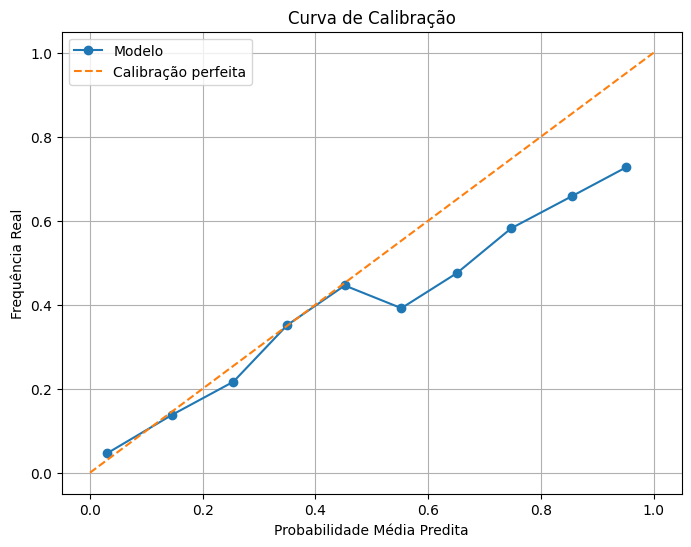


=== FEATURE IMPORTANCE ===
                           Feature  Importance
18                   Contract_Long    0.135038
13                    TotalCharges    0.097778
12                  MonthlyCharges    0.094566
16                     Avg_Charges    0.090431
27  PaymentMethod_Electronic check    0.061806
19                 Services_Weight    0.056297
22     InternetService_Fiber optic    0.053819
25               Contract_Two year    0.035873
5                   OnlineSecurity    0.034521
2                       Dependents    0.030698
20                        Is_Loyal    0.026956
8                      TechSupport    0.024569
1                          Partner    0.021693
14                       Total_SVA    0.020942
15                High_Risk_Newbie    0.018289


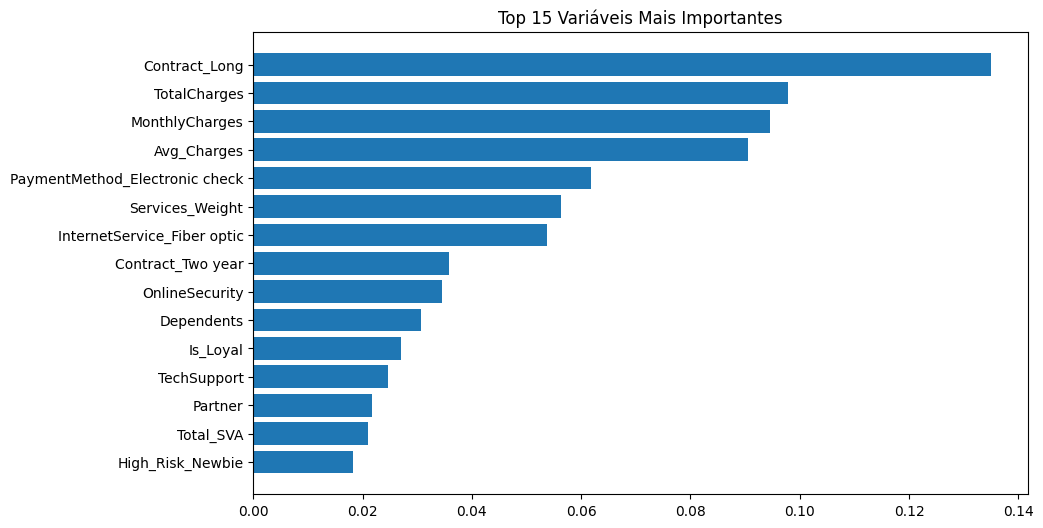

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score
)

from imblearn.combine import SMOTETomek

# ======================================================
# 1. CARGA E LIMZA
# ======================================================

df = pd.read_csv("Customer-Churn.csv")

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

# tratamento de outliers
for col in ["MonthlyCharges", "TotalCharges"]:
    limite = df[col].quantile(0.99)
    df[col] = np.where(df[col] > limite, limite, df[col])

# ======================================================
# 2. FEATURE ENGINEERING
# ======================================================

def categorizar_tenure(t):
    if t <= 6:
        return "Novo"
    elif t <= 24:
        return "Medio"
    return "Antigo"

df["tenure_group"] = df["tenure"].apply(categorizar_tenure)

sva_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["Total_SVA"] = (df[sva_cols] == "Yes").sum(axis=1)

df["High_Risk_Newbie"] = (
    (df["tenure"] <= 6) &
    (df["Contract"] == "Month-to-month")
).astype(int)

df["Avg_Charges"] = df["TotalCharges"] / (df["tenure"] + 1)
df["Is_Expensive"] = (
    df["MonthlyCharges"] > df["MonthlyCharges"].median()
).astype(int)

df["Contract_Long"] = (
    df["Contract"] != "Month-to-month"
).astype(int)

df["Services_Weight"] = (
    df["Total_SVA"] * df["MonthlyCharges"]
)

df["Is_Loyal"] = (
    df["tenure"] > 24
).astype(int)

# ======================================================
# 3. CONVERSÃO BINÁRIA
# ======================================================

yes_no_cols = [
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "MultipleLines"
]

for col in yes_no_cols:
    df[col] = df[col].replace({
        "Yes": 1,
        "No": 0,
        "No internet service": 0,
        "No phone service": 0
    })

# ======================================================
# 4. ENCODING
# ======================================================

cat_cols = [
    "gender",
    "InternetService",
    "Contract",
    "PaymentMethod",
    "tenure_group"
]

df_final = pd.get_dummies(
    df.drop(columns=["customerID", "tenure"]),
    columns=cat_cols,
    drop_first=True
)

# ======================================================
# 5. CLUSTERIZAÇÃO (KMEANS)
# ======================================================

cluster_features = df_final[
    ["MonthlyCharges", "TotalCharges", "Total_SVA"]
].copy()

scaler_cluster = StandardScaler()
cluster_scaled = scaler_cluster.fit_transform(cluster_features)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df_final["Cluster"] = kmeans.fit_predict(cluster_scaled)

print("\n=== DISTRIBUIÇÃO DOS CLUSTERS ===")
print(df_final["Cluster"].value_counts())

# ======================================================
# 6. SPLIT
# ======================================================

X = df_final.drop("Churn", axis=1)
y = df_final["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())

# ======================================================
# 7. BALANCEAMENTO
# ======================================================

smote = SMOTETomek(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

# ======================================================
# 8. ESCALA
# ======================================================

scaler = StandardScaler()

# RF sem escala
X_res_rf = X_res
X_test_rf = X_test

# LR + MLP com escala
X_res_scaled = scaler.fit_transform(X_res)
X_test_scaled = scaler.transform(X_test)

# ======================================================
# 9. MODELOS
# ======================================================

rf_model = RandomForestClassifier(
    random_state=42,
    class_weight={0: 1, 1: 2},
    n_estimators=500,
    max_depth=20
)

lr_model = LogisticRegression(
    max_iter=1000,
    C=1
)

mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    max_iter=1000,
    random_state=42
)

rf_model.fit(X_res_rf, y_res)
lr_model.fit(X_res_scaled, y_res)
mlp_model.fit(X_res_scaled, y_res)

# ======================================================
# 10. COMPARAÇÃO REAL
# ======================================================

kf = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

rf_score = cross_val_score(
    rf_model,
    X_res_rf,
    y_res,
    cv=kf,
    scoring="recall"
).mean()

lr_score = cross_val_score(
    lr_model,
    X_res_scaled,
    y_res,
    cv=kf,
    scoring="recall"
).mean()

mlp_score = cross_val_score(
    mlp_model,
    X_res_scaled,
    y_res,
    cv=kf,
    scoring="recall"
).mean()

print("\n=== RECALL MÉDIO ===")
print(f"Random Forest: {rf_score:.4f}")
print(f"Regressão Logística: {lr_score:.4f}")
print(f"MLP: {mlp_score:.4f}")

# ======================================================
# 11. MELHOR MODELO
# ======================================================

scores = {
    "RF": rf_score,
    "LR": lr_score,
    "MLP": mlp_score
}

best_name = max(scores, key=scores.get)
print(f"\n🏆 Melhor Modelo: {best_name}")

if best_name == "RF":
    best_model = rf_model
    probs = best_model.predict_proba(X_test_rf)[:, 1]
else:
    best_model = lr_model if best_name == "LR" else mlp_model
    probs = best_model.predict_proba(X_test_scaled)[:, 1]

# ======================================================
# 12. THRESHOLD
# ======================================================

threshold = 0.35
preds = (probs >= threshold).astype(int)

# ======================================================
# 13. MÉTRICAS FINAIS
# ======================================================

print("\n=== RESULTADO FINAL ===")

print("Accuracy:", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall:", recall_score(y_test, preds))
print("F1-Score:", f1_score(y_test, preds))

cm = confusion_matrix(y_test, preds)

ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.title(f"Matriz de Confusão - {best_name}")
plt.show()

# ======================================================
# 14. SHAP (INTERPRETABILIDADE)
# ======================================================

print("\n=== PROCESSANDO SHAP ===")

# SHAP funciona melhor com Random Forest
if best_name == "RF":

    explainer = shap.TreeExplainer(best_model)

    shap_values = explainer.shap_values(X_test_rf)

    print("\nGerando gráfico SHAP Summary Plot...")

    shap.summary_plot(
        shap_values[:, :, 1],   # classe churn = 1
        X_test_rf,
        plot_type="dot"
    )

else:
    print("\nSHAP completo foi aplicado apenas ao Random Forest.")
    print("Para LR e MLP, a análise principal permanece no RF por melhor interpretabilidade.")

    # ======================================================
# 15. VALIDAÇÃO CIENTÍFICA + CALIBRAÇÃO + EXPLICABILIDADE
# ======================================================

from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score, precision_recall_curve
from scipy.stats import wilcoxon

print("\n=== VALIDAÇÃO CIENTÍFICA ===")

# -------------------------------
# ROC-AUC FINAL
# -------------------------------

roc_auc = roc_auc_score(y_test, probs)
print(f"ROC-AUC Final: {roc_auc:.4f}")

# -------------------------------
# CURVA PRECISION-RECALL
# -------------------------------

precision_curve, recall_curve, thresholds_curve = precision_recall_curve(
    y_test,
    probs
)

plt.figure(figsize=(8,6))
plt.plot(recall_curve, precision_curve)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.grid()
plt.show()

# ======================================================
# 16. TESTE ESTATÍSTICO DE WILCOXON
# ======================================================

print("\n=== TESTE DE WILCOXON ===")

# Cross-validation individual (sem média)
rf_scores_full = cross_val_score(
    rf_model,
    X_res_rf,
    y_res,
    cv=kf,
    scoring="recall"
)

lr_scores_full = cross_val_score(
    lr_model,
    X_res_scaled,
    y_res,
    cv=kf,
    scoring="recall"
)

mlp_scores_full = cross_val_score(
    mlp_model,
    X_res_scaled,
    y_res,
    cv=kf,
    scoring="recall"
)

# RF vs LR
stat_rf_lr, p_rf_lr = wilcoxon(rf_scores_full, lr_scores_full)

# RF vs MLP
stat_rf_mlp, p_rf_mlp = wilcoxon(rf_scores_full, mlp_scores_full)

print(f"RF vs LR -> p-value: {p_rf_lr:.4f}")
print(f"RF vs MLP -> p-value: {p_rf_mlp:.4f}")

if p_rf_lr < 0.05:
    print("Diferença estatisticamente significativa entre RF e LR")
else:
    print("Sem diferença estatisticamente significativa entre RF e LR")

if p_rf_mlp < 0.05:
    print("Diferença estatisticamente significativa entre RF e MLP")
else:
    print("Sem diferença estatisticamente significativa entre RF e MLP")

# ======================================================
# 17. CURVA DE CALIBRAÇÃO
# ======================================================

print("\n=== CURVA DE CALIBRAÇÃO ===")

prob_true, prob_pred = calibration_curve(
    y_test,
    probs,
    n_bins=10
)

plt.figure(figsize=(8,6))
plt.plot(prob_pred, prob_true, marker='o', label="Modelo")
plt.plot([0, 1], [0, 1], linestyle='--', label="Calibração perfeita")

plt.xlabel("Probabilidade Média Predita")
plt.ylabel("Frequência Real")
plt.title("Curva de Calibração")
plt.legend()
plt.grid()
plt.show()

# ======================================================
# 18. EXPLICABILIDADE EXTRA (FEATURE IMPORTANCE RF)
# ======================================================

print("\n=== FEATURE IMPORTANCE ===")

if best_name == "RF":

    importances = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": best_model.feature_importances_
    })

    importances = importances.sort_values(
        by="Importance",
        ascending=False
    ).head(15)

    print(importances)

    plt.figure(figsize=(10,6))
    plt.barh(
        importances["Feature"],
        importances["Importance"]
    )
    plt.title("Top 15 Variáveis Mais Importantes")
    plt.gca().invert_yaxis()
    plt.show()

else:
    print("Feature Importance detalhada foi mantida no Random Forest.")


=== COMPARAÇÃO DOS MODELOS ===
                Modelo  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0        Random Forest  0.757275   0.529740  0.762032  0.625000  0.826856
1  Logistic Regression  0.743790   0.511670  0.762032  0.612245  0.830241
2                  MLP  0.746629   0.518359  0.641711  0.573477  0.797068


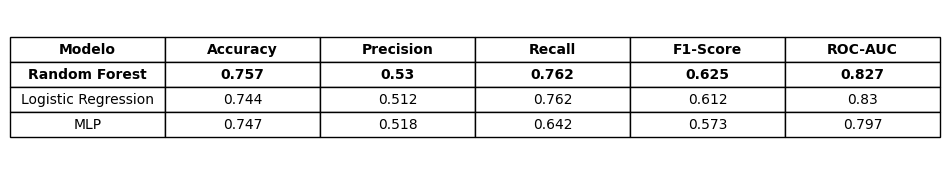

In [ ]:
# ======================================================
# AVALIAÇÃO COMPLETA DOS MODELOS (TESTE)
# ======================================================

def avaliar_modelo(nome, modelo, X_test, y_test, scaled=False):

    if scaled:
        probs = modelo.predict_proba(X_test_scaled)[:, 1]
        preds = (probs >= threshold).astype(int)
    else:
        probs = modelo.predict_proba(X_test_rf)[:, 1]
        preds = (probs >= threshold).astype(int)

    return {
        "Modelo": nome,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1-Score": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, probs)
    }

# criando lista com resultados
resultados = []

resultados.append(avaliar_modelo("Random Forest", rf_model, X_test_rf, y_test, scaled=False))
resultados.append(avaliar_modelo("Logistic Regression", lr_model, X_test_scaled, y_test, scaled=True))
resultados.append(avaliar_modelo("MLP", mlp_model, X_test_scaled, y_test, scaled=True))

# transformar em DataFrame
df_resultados = pd.DataFrame(resultados)

print("\n=== COMPARAÇÃO DOS MODELOS ===")
print(df_resultados)

import pandas as pd
import matplotlib.pyplot as plt

# ================================
# DADOS (SEUS RESULTADOS)
# ================================

data = {
    "Modelo": ["Random Forest", "Logistic Regression", "MLP"],
    "Accuracy": [0.757275, 0.743790, 0.746629],
    "Precision": [0.529740, 0.511670, 0.518359],
    "Recall": [0.762032, 0.762032, 0.641711],
    "F1-Score": [0.625000, 0.612245, 0.573477],
    "ROC-AUC": [0.826856, 0.830241, 0.797068]
}

df = pd.DataFrame(data)

# arredondar para ficar bonito
df = df.round(3)

# ================================
# CRIAR TABELA COMO IMAGEM
# ================================

fig, ax = plt.subplots(figsize=(10, 2))
ax.axis('off')

tabela = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    loc='center',
    cellLoc='center'
)

# ================================
# ESTILO
# ================================

tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.5)

# cabeçalho em negrito
for (row, col), cell in tabela.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')

# destacar melhor modelo (linha 1 = RF)
for col in range(len(df.columns)):
    tabela[(1, col)].set_text_props(weight='bold')

# ================================
# SALVAR IMAGEM
# ================================

plt.savefig("tabela_resultados.png", bbox_inches='tight', dpi=300)

plt.show()